In [1]:
from TKA_SHA_Mo_240503_2_copy import K0, dfg, calc_eq_methanation, phi_Soave
import numpy as np
from scipy.constants import R

In [2]:
T = np.linspace(400, 900, 50) + 273.15 # K

dfG_vals = np.zeros((len(T), 7))
dRGs_RWGS = np.zeros(len(T))
dRGS_CO_methanation = np.zeros(len(T))
dRGS_CO2_methanation = np.zeros(len(T))

K0_dfG = np.zeros((len(T), 3))

for i, t in enumerate(T):
    dfG_vals[i, :] = dfg(t)
    dRGs_RWGS[i] = dfG_vals[i, 3] + dfG_vals[i, 4] - dfG_vals[i, 0] - 2 * dfG_vals[i, 1]
    dRGS_CO_methanation[i] = dfG_vals[i, 2] + dfG_vals[i, 3] - 3 * dfG_vals[i, 1] - dfG_vals[i, 4]
    dRGS_CO2_methanation[i] = dfG_vals[i, 2] + 2 * dfG_vals[i, 3] - 4 * dfG_vals[i, 1] - dfG_vals[i, 0]

    K0_dfG[i, 0] = np.exp(-dRGs_RWGS[i] / (R * t))
    K0_dfG[i, 1] = np.exp(-dRGS_CO_methanation[i] / (R * t))
    K0_dfG[i, 2] = np.exp(-dRGS_CO2_methanation[i] / (R * t))

In [3]:
# calculate drG from K0 values

K0_vals = np.zeros((len(T), 3))
DRG_vals_RWGS = np.zeros(len(T))
DRG_vals_CO_methanation = np.zeros(len(T))
DRG_vals_CO2_methanation = np.zeros(len(T))


for i, t in enumerate(T):
    K0_vals[i, 0] = K0(t, 'WGS') ** (-1)
    K0_vals[i, 1] = K0(t, 'CO methanation')
    K0_vals[i, 2] = K0(t, 'CO2 methanation')
    DRG_vals_RWGS[i] = - R * t * np.log(K0_vals[i, 0])
    DRG_vals_CO_methanation[i] = - R * t * np.log(K0_vals[i, 1])
    DRG_vals_CO2_methanation[i] = - R * t * np.log(K0_vals[i, 2])

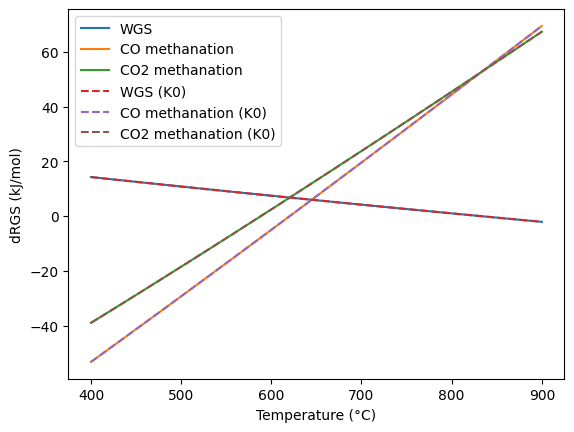

In [4]:
# plot dRGS vs T in kJ/mol
import matplotlib.pyplot as plt
plt.plot(T - 273.15, dRGs_RWGS / 1e3, label='WGS')
plt.plot(T - 273.15, dRGS_CO_methanation / 1e3, label='CO methanation')
plt.plot(T - 273.15, dRGS_CO2_methanation / 1e3, label='CO2 methanation')
plt.plot(T - 273.15, DRG_vals_RWGS / 1e3, '--', label='WGS (K0)')
plt.plot(T - 273.15, DRG_vals_CO_methanation / 1e3, '--', label='CO methanation (K0)')
plt.plot(T - 273.15, DRG_vals_CO2_methanation / 1e3, '--', label='CO2 methanation (K0)')
plt.xlabel('Temperature (°C)')
plt.ylabel('dRGS (kJ/mol)')
plt.legend()
plt.show()

# calculate relative error between dRGS and DRG
error_RWGS = np.abs(dRGs_RWGS - DRG_vals_RWGS) / np.abs(DRG_vals_RWGS)
error_CO_methanation = np.abs(dRGS_CO_methanation - DRG_vals_CO_methanation) / np.abs(DRG_vals_CO_methanation)
error_CO2_methanation = np.abs(dRGS_CO2_methanation - DRG_vals_CO2_methanation) / np.abs(DRG_vals_CO2_methanation)

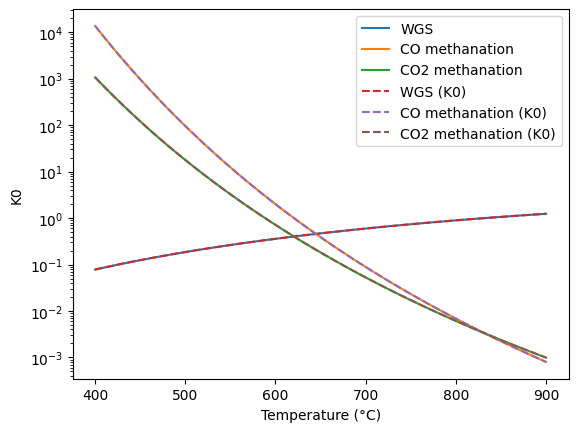

In [5]:
plt.plot(T - 273.15, K0_dfG[:, 0], label='WGS')
plt.plot(T - 273.15, K0_dfG[:, 1], label='CO methanation')
plt.plot(T - 273.15, K0_dfG[:, 2], label='CO2 methanation')
plt.plot(T - 273.15, K0_vals[:, 0], '--', label='WGS (K0)')
plt.plot(T - 273.15, K0_vals[:, 1], '--', label='CO methanation (K0)')
plt.plot(T - 273.15, K0_vals[:, 2], '--', label='CO2 methanation (K0)')
plt.xlabel('Temperature (°C)')
plt.ylabel('K0')
plt.legend()
plt.yscale('log')
plt.show()

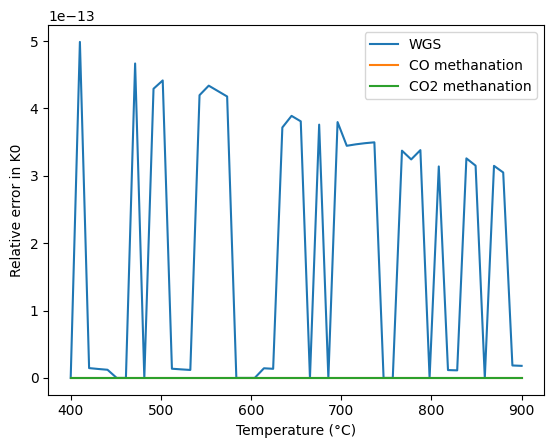

In [6]:
K0_error_WGS = np.abs((K0_dfG[:, 0] - K0_vals[:, 0]) / K0_vals[:, 0]) * 100
K0_error_CO_methanation = np.abs((K0_dfG[:, 1] - K0_vals[:, 1]) / K0_vals[:, 1]) * 100
K0_error_CO2_methanation = np.abs((K0_dfG[:, 2] - K0_vals[:, 2]) / K0_vals[:, 2]) * 100

plt.plot(T - 273.15, K0_error_WGS, label='WGS')
plt.plot(T - 273.15, K0_error_CO_methanation, label='CO methanation')
plt.plot(T - 273.15, K0_error_CO2_methanation, label='CO2 methanation')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative error in K0')
plt.legend()
plt.show()

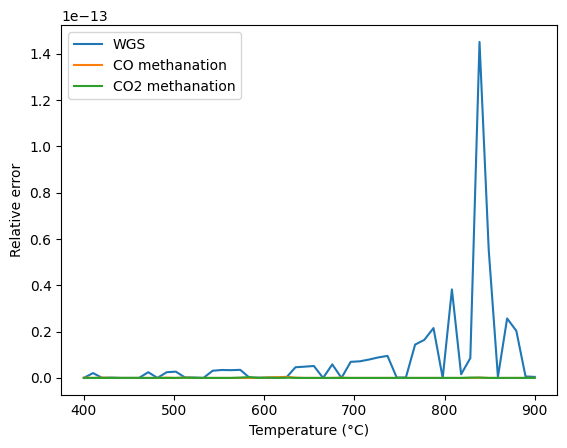

In [7]:
# plot relative error
plt.plot(T - 273.15, error_RWGS, label='WGS')
plt.plot(T - 273.15, error_CO_methanation, label='CO methanation')
plt.plot(T - 273.15, error_CO2_methanation, label='CO2 methanation')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative error')
plt.legend()
plt.show()

In [8]:
 #CO2, H2, CH4, H2O, CO, C and N2

In [9]:
T = np.linspace(200, 900, 50) + 273.15 # K

K0_WGS_dfG = np.zeros(len(T))
K0_CO_meth_dfG = np.zeros(len(T))
K0_CO2_meth_dfG = np.zeros(len(T))


for i, t in enumerate(T):
     #CO2, H2, CH4, H2O, CO, C and N2
    dfG_vals = dfg(t)
    dRGs_WGS = - dfG_vals[3] - dfG_vals[4] + dfG_vals[0] + dfG_vals[1]
    K0_WGS_dfG[i] = np.exp(-dRGs_WGS / (R * t))
    dRGS_CO_meth = dfG_vals[2] + dfG_vals[3] - 3 * dfG_vals[1] - dfG_vals[4]
    K0_CO_meth_dfG[i] = np.exp(-dRGS_CO_meth / (R * t))
    dRGS_CO2_meth = dfG_vals[2] + 2 * dfG_vals[3] - 4 * dfG_vals[1] - dfG_vals[0]
    K0_CO2_meth_dfG[i] = np.exp(-dRGS_CO2_meth / (R * t))



In [10]:
# now calculate the equilbrium composition of the WGS reaction

#T = np.linspace(100, 900, 50) + 273.15 # K
p = 1e5 # Pa

x_0 = np.array([0.2, 0.8-5e-20, 1e-20, 1e-20, 1e-20, 1e-20, 1e-20]) # 1
x_eq = np.zeros((len(T), 7))
fug_coeffs = np.zeros((len(T), 6))

for i, t in enumerate(T):

    p, T_s, x0, x_GG, succ = calc_eq_methanation(t, p, x_0, 'ideal gas')
    x_eq[i, :] = x_GG
    # check if any x_eq_val is 1e-20
    #if np.any(x_eq[i, :] <= 1e-20):
    #    print('Warning: x_eq has values < 1e-20')
    #print(f'For T = {t-273.15:.2f}°C, the equilibrium composition is:')

    fug_coeffs[i, :] = phi_Soave(np.delete(x_eq[i, :], 5), t, p)

/Users/johannesgeri/Documents/Master/HiWi/ANNs/gibbsenergyminimizationmodel/TKA_SHA_Mo_240503_2_copy.py:409: RuntimeWarning: overflow encountered in scalar divide
  K_0_sim = (y_GG[2] * y_GG[0]) / (y_GG[4]**2 * y_GG[1]**2) / p_bar ** 2 * (fug_coeffs[2] * fug_coeffs[0]) / (fug_coeffs[4]**2 * fug_coeffs[1]**2)
/Users/johannesgeri/Documents/Master/HiWi/ANNs/gibbsenergyminimizationmodel/TKA_SHA_Mo_240503_2_copy.py:400: RuntimeWarning: divide by zero encountered in scalar divide
  K_0_sim = (y_GG[2] * y_GG[3] ** 2) / (y_GG[0] * y_GG[1] ** 4) / p_bar ** 2 * (fug_coeffs[2] * fug_coeffs[3]**2) / (fug_coeffs[0] * fug_coeffs[1]**4)
/Users/johannesgeri/Documents/Master/HiWi/ANNs/gibbsenergyminimizationmodel/TKA_SHA_Mo_240503_2_copy.py:403: RuntimeWarning: divide by zero encountered in scalar divide
  K_0_sim = (y_GG[2] * y_GG[3]) / (y_GG[4] * y_GG[1] ** 3) / p_bar**2 * (fug_coeffs[2] * fug_coeffs[3]) / (fug_coeffs[4] * fug_coeffs[1] ** 3)
/Users/johannesgeri/Documents/Master/HiWi/ANNs/gibbsenergy

In [11]:
x_eq

array([[4.11809980e-03, 1.64199352e-02, 3.26505028e-01, 6.52956281e-01,
        6.56041752e-07, 9.96290430e-11, 1.65298284e-20],
       [1.29845414e-01, 6.44880712e-01, 1.49856888e-02, 1.49125012e-01,
        3.17271124e-03, 5.79904617e-02, 1.02997138e-20],
       [1.68920626e-01, 7.68920532e-01, 6.17356795e-10, 3.10794075e-02,
        3.10793486e-02, 8.56487173e-08, 1.00000000e-20],
       [1.65066121e-01, 7.65065797e-01, 1.00000000e-20, 3.49341498e-02,
        3.49334497e-02, 4.82295792e-07, 1.00000000e-20],
       [           nan,            nan,            nan,            nan,
                   nan,            nan,            nan],
       [1.57107302e-01, 7.57107302e-01, 1.00000000e-20, 4.28926978e-02,
        4.28926979e-02, 1.00000000e-20, 1.00000000e-20],
       [1.52929892e-01, 7.52951441e-01, 3.66387942e-15, 4.70233581e-02,
        4.70948859e-02, 4.22546231e-07, 1.00000000e-20],
       [3.33333333e-11, 3.24380182e-11, 3.33333333e-01, 6.66666667e-01,
        1.00000000e-20, 1

# K0 WGS

In [12]:
K0_WGS_Gmin = np.zeros(len(T))
K0_CO_meth_Gmin = np.zeros(len(T))
K0_CO2_meth_Gmin = np.zeros(len(T))

for i, t in enumerate(T):

    # check if any value in x_eq is smaller than 1e-20
    if np.any(x_eq[i, :-1] <= 1e-20):
        #print('Warning: x_eq has values < 1e-20')
        K0_WGS_Gmin[i] = np.nan
        K0_CO_meth_Gmin[i] = np.nan
        K0_CO2_meth_Gmin[i] = np.nan
        print(i, x_eq[i, :])

    else:

        print('yay', t)
         #CO2, H2, CH4, H2O, CO, C and N2
    
        K0_WGS_Gmin[i] = x_eq[i, 0] * x_eq[i, 1] / (x_eq[i, 3] * x_eq[i, 4]) #* fug_coeffs[i, 0] * fug_coeffs[i, 1] / (fug_coeffs[i, 3] * fug_coeffs[i, 4])
        K0_CO_meth_Gmin[i] = x_eq[i, 2] * x_eq[i, 3] / (x_eq[i, 1] ** 3 * x_eq[i, 4]) * fug_coeffs[i, 2] * fug_coeffs[i, 3] / (fug_coeffs[i, 1] ** 3 * fug_coeffs[i, 4])
        K0_CO2_meth_Gmin[i] = x_eq[i, 2] * x_eq[i, 3] ** 2 / (x_eq[i, 1] ** 4 * x_eq[i, 0]) * fug_coeffs[i, 2] * fug_coeffs[i, 3] ** 2 / (fug_coeffs[i, 1] ** 4 * fug_coeffs[i, 0])

yay 473.15
yay 487.43571428571425
yay 501.72142857142853
3 [1.65066121e-01 7.65065797e-01 1.00000000e-20 3.49341498e-02
 3.49334497e-02 4.82295792e-07 1.00000000e-20]
yay 530.2928571428572
5 [1.57107302e-01 7.57107302e-01 1.00000000e-20 4.28926978e-02
 4.28926979e-02 1.00000000e-20 1.00000000e-20]
yay 558.8642857142856
7 [3.33333333e-11 3.24380182e-11 3.33333333e-01 6.66666667e-01
 1.00000000e-20 1.00000000e-20 1.66666667e-20]
yay 587.4357142857143
9 [2.e-01 8.e-01 1.e-20 1.e-20 1.e-20 1.e-20 1.e-20]
10 [2.e-01 8.e-01 1.e-20 1.e-20 1.e-20 1.e-20 1.e-20]
11 [2.e-01 8.e-01 1.e-20 1.e-20 1.e-20 1.e-20 1.e-20]
12 [1.99998185e-01 7.99998185e-01 2.16344942e-12 1.81495606e-06
 1.81495599e-06 1.00000000e-20 1.00000000e-20]
13 [2.e-01 8.e-01 1.e-20 1.e-20 1.e-20 1.e-20 1.e-20]
14 [2.e-01 8.e-01 1.e-20 1.e-20 1.e-20 1.e-20 1.e-20]
15 [2.e-01 8.e-01 1.e-20 1.e-20 1.e-20 1.e-20 1.e-20]
16 [1.99978462e-01 7.99977476e-01 1.00000000e-20 2.22983297e-05
 2.01019002e-05 1.66118957e-06 1.00000000e-20]
17

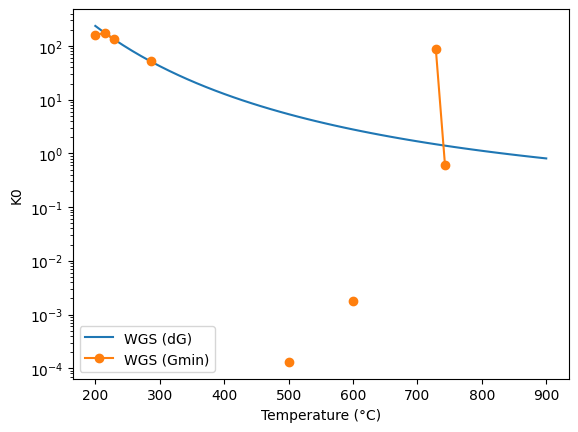

In [13]:
# plot both K0 values

plt.plot(T - 273.15, K0_WGS_dfG, label='WGS (dG)')
plt.plot(T - 273.15, K0_WGS_Gmin, label='WGS (Gmin)', marker='o')
#plt.plot(T - 273.15, K0_CO_meth_dfG, label='CO methanation (dG)')
#plt.plot(T - 273.15, K0_CO_meth_Gmin, label='CO methanation (Gmin)', marker='o')
#plt.plot(T - 273.15, K0_CO2_meth_dfG, label='CO2 methanation (dG)')
#plt.plot(T - 273.15, K0_CO2_meth_Gmin, label='CO2 methanation (Gmin)', marker='o')
plt.xlabel('Temperature (°C)')
plt.ylabel('K0')
#plt.ylim(-100, 1e5)
plt.yscale('log')
plt.legend()
plt.show()

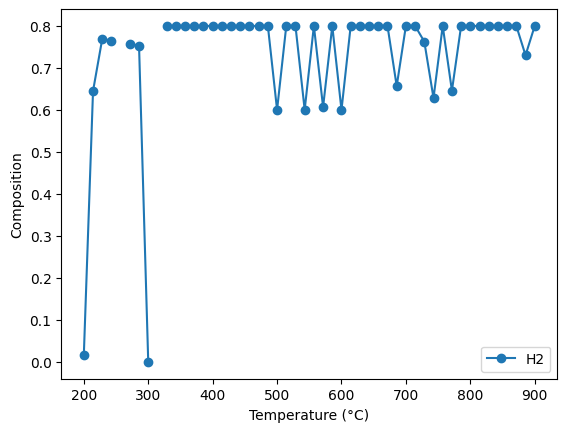

In [14]:
# plot equilibrium composition
#plt.plot(T - 273.15, x_eq[:, 0], label='CO2')
plt.plot(T - 273.15, x_eq[:, 1], label='H2', marker='o')
#plt.plot(T - 273.15, x_eq[:, 2], label='CH4')
#plt.plot(T - 273.15, x_eq[:, 3], label='H2O')
#plt.plot(T - 273.15, x_eq[:, 4], label='CO')
#plt.plot(T - 273.15, x_eq[:, 5], label='C')
#plt.plot(T - 273.15, x_eq[:, 6], label='N2')
plt.xlabel('Temperature (°C)')
plt.ylabel('Composition')
plt.legend()
plt.show()

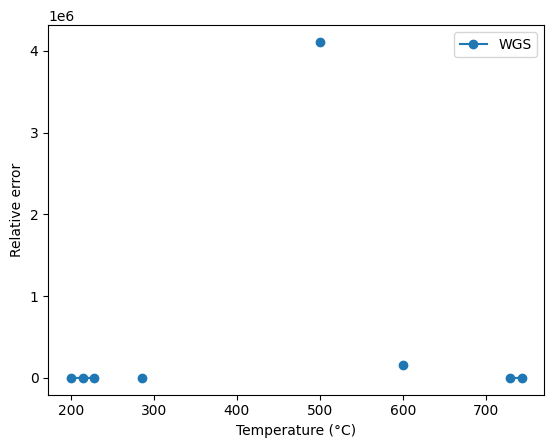

In [15]:
# plot relative deviation between K0 WGS dfG and Gmin

error_WGS = np.abs((K0_WGS_dfG - K0_WGS_Gmin) / K0_WGS_Gmin * 100)

plt.plot(T - 273.15, error_WGS, label='WGS', marker='o')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative error')
plt.legend()
plt.show()